## Introduction & Research Questions
This project analyzes a Sleep Health and Lifestyle dataset to explore how lifestyle factors (physical activity, stress, age) relate to sleep outcomes (sleep duration, sleep quality) and sleep disorders.

**Research Questions**
- Does higher physical activity relate to better sleep quality?
- Does higher stress relate to shorter sleep duration?
- How are age and sleep duration related?
- Is gender associated with sleep disorder status?


In [27]:
import pandas as pd
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()



Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (2).csv


In [28]:
# Read the CSV file you uploaded
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Show the first few rows to check that it loaded correctly
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [29]:
# Split Blood Pressure into numeric columns
bp_split = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(bp_split[0], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(bp_split[1], errors='coerce')

# List of continuous numeric columns
numeric_columns = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic_BP',
    'Diastolic_BP'
]

# Calculate mean, median, and standard deviation
mean_values = df[numeric_columns].mean()
median_values = df[numeric_columns].median()
std_values = df[numeric_columns].std()

# Combine in a nice table
summary_df = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Standard Deviation': std_values
})

summary_df


,Mean,Median,Standard Deviation
Age,42.184492,43.0,8.673133
Sleep Duration,7.132086,7.2,0.795657
Quality of Sleep,7.312834,7.0,1.196956
Physical Activity Level,59.171123,60.0,20.830804
Stress Level,5.385027,5.0,1.774526
Heart Rate,70.165775,70.0,4.135676
Daily Steps,6816.844920,7000.0,1617.915679
Systolic_BP,128.553476,130.0,7.748118
Diastolic_BP,84.649733,85.0,6.161611


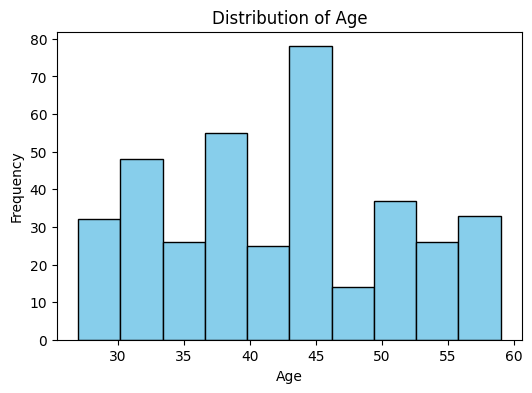

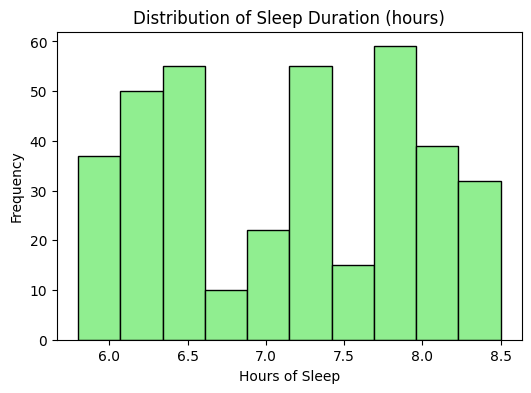

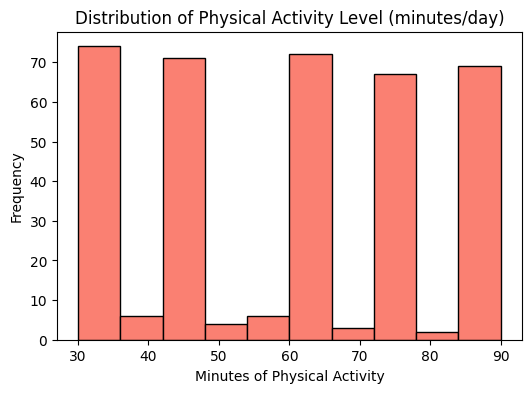

In [30]:
import matplotlib.pyplot as plt

# Histogram for Age
plt.figure(figsize=(6, 4))
plt.hist(df['Age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Histogram for Sleep Duration
plt.figure(figsize=(6, 4))
plt.hist(df['Sleep Duration'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Sleep Duration (hours)')
plt.xlabel('Hours of Sleep')
plt.ylabel('Frequency')
plt.show()

# Histogram for Physical Activity Level
plt.figure(figsize=(6, 4))
plt.hist(df['Physical Activity Level'], bins=10, color='salmon', edgecolor='black')
plt.title('Distribution of Physical Activity Level (minutes/day)')
plt.xlabel('Minutes of Physical Activity')
plt.ylabel('Frequency')
plt.show()


<Figure size 1200x600 with 0 Axes>

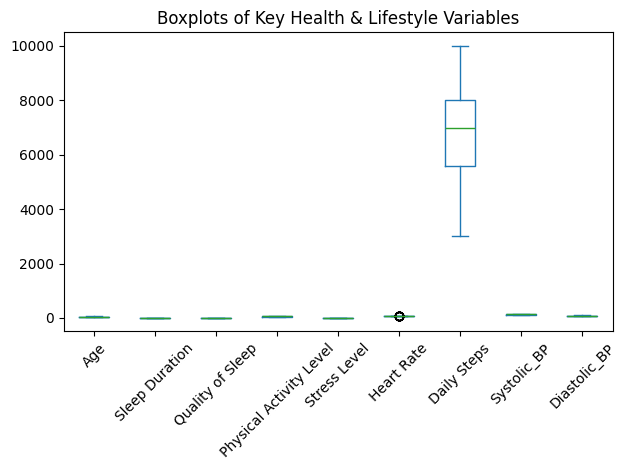

In [31]:
# Boxplots for numeric columns (EDA requirement)
plt.figure(figsize=(12,6))
df[numeric_columns].plot(kind='box')
plt.title("Boxplots of Key Health & Lifestyle Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Hypothesis Testing:
import scipy.stats as stats

# HYPOTHESIS 1
print("\nHYPOTHESIS 1")
print("H0: The mean Quality of Sleep is the same for high and low physical activity groups.")
print("H1: The mean Quality of Sleep is different for high and low physical activity groups.")
print("Test: Welch's two-sample t-test (alpha = 0.05)\n")

# Define groups for Hypothesis 1
group_high_activity = df[df['Physical Activity Level'] > 60]['Quality of Sleep']
group_low_activity = df[df['Physical Activity Level'] <= 60]['Quality of Sleep']

# Perform two-sample t-test
t_stat1, p_val1 = stats.ttest_ind(group_high_activity, group_low_activity, equal_var=False)


print(f"T-statistic: {t_stat1:.4f}")
print(f"P-value: {p_val1:.4f}")


alpha = 0.05

if p_val1 < alpha:
    print("Result: Reject the null hypothesis (significant difference).")
else:
    print("Result: Fail to reject the null hypothesis (no significant difference).")



HYPOTHESIS 1
H0: The mean Quality of Sleep is the same for high and low physical activity groups.
H1: The mean Quality of Sleep is different for high and low physical activity groups.
Test: Welch's two-sample t-test (alpha = 0.05)

T-statistic: 3.6172
P-value: 0.0003
Result: Reject the null hypothesis (significant difference).


In [33]:
# HYPOTHESIS 2
print("\nHYPOTHESIS 2")
print("H0: The mean Sleep Duration is the same for high and low stress groups.")
print("H1: The mean Sleep Duration is different for high and low stress groups.")
print("Test: Welch's two-sample t-test (alpha = 0.05)\n")

# Groups for Hypothesis 2
group_high_stress = df[df['Stress Level'] > 5]['Sleep Duration']
group_low_stress = df[df['Stress Level'] <= 5]['Sleep Duration']

# Perform the two‑sample t‑test
t_stat2, p_val2 = stats.ttest_ind(group_high_stress, group_low_stress, equal_var=False)


print(f"T‑statistic: {t_stat2:.4f}")
print(f"P‑value: {p_val2:.4f}")


alpha = 0.05

if p_val2 < alpha:
    print("Result: Reject the null hypothesis (significant difference).")
else:
    print("Result: Fail to reject the null hypothesis (no significant difference).")



HYPOTHESIS 2
H0: The mean Sleep Duration is the same for high and low stress groups.
H1: The mean Sleep Duration is different for high and low stress groups.
Test: Welch's two-sample t-test (alpha = 0.05)

T‑statistic: -15.7988
P‑value: 0.0000
Result: Reject the null hypothesis (significant difference).


In [34]:
def interpret_r(r):
    direction = "positive" if r > 0 else "negative" if r < 0 else "no"
    ar = abs(r)
    if ar < 0.1:
        strength = "negligible"
    elif ar < 0.3:
        strength = "weak"
    elif ar < 0.5:
        strength = "moderate"
    else:
        strength = "strong"
    return strength, direction


Pearson Correlation (Age vs Sleep Duration):
r = 0.3447
p‑value = 0.0000


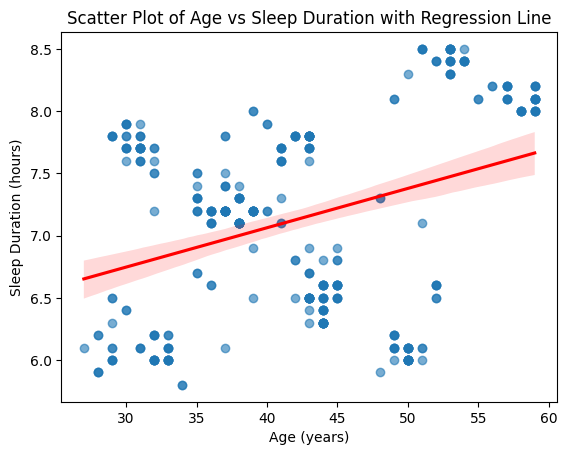

In [35]:
#PEARSON CORRELATION
from scipy.stats import pearsonr

# Pearson correlation between Age and Sleep Duration
r_age_sleep, p_age_sleep = pearsonr(df['Age'], df['Sleep Duration'])

print("Pearson Correlation (Age vs Sleep Duration):")
print(f"r = {r_age_sleep:.4f}")
print(f"p‑value = {p_age_sleep:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt



sns.regplot(x='Age', y='Sleep Duration', data=df, scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title('Scatter Plot of Age vs Sleep Duration with Regression Line')
plt.xlabel('Age (years)')
plt.ylabel('Sleep Duration (hours)')
plt.show()


In [36]:
strength, direction = interpret_r(r_age_sleep)
print(f"Interpretation: {strength} {direction} relationship between Age and Sleep Duration.")


Interpretation: moderate positive relationship between Age and Sleep Duration.


Spearman Correlation (Sleep Duration vs Quality of Sleep):
rho = 0.8874
p‑value = 0.0000


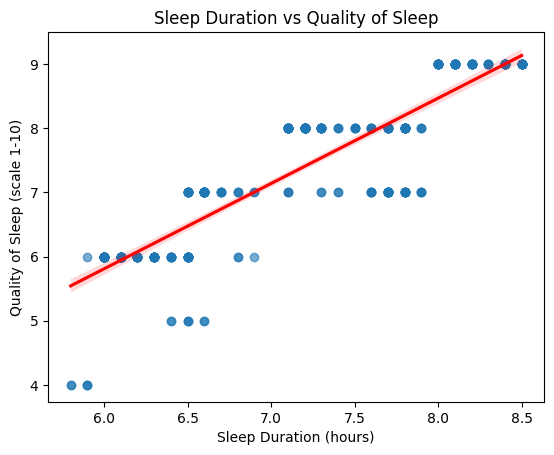

In [37]:
from scipy.stats import spearmanr

# Spearman correlation between Sleep Duration and Quality of Sleep
rho_sleep_quality, p_sleep_quality = spearmanr(df['Sleep Duration'], df['Quality of Sleep'])

print("Spearman Correlation (Sleep Duration vs Quality of Sleep):")
print(f"rho = {rho_sleep_quality:.4f}")
print(f"p‑value = {p_sleep_quality:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot with regression (trend) line
sns.regplot(x='Sleep Duration', y='Quality of Sleep', data=df, scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title('Sleep Duration vs Quality of Sleep')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Quality of Sleep (scale 1-10)')
plt.show()


In [38]:
strength, direction = interpret_r(rho_sleep_quality)
print(f"Interpretation: {strength} {direction} monotonic relationship between Sleep Duration and Quality of Sleep.")


Interpretation: strong positive monotonic relationship between Sleep Duration and Quality of Sleep.


In [39]:
from scipy.stats import kendalltau

tau, p_tau = kendalltau(df['Sleep Duration'], df['Quality of Sleep'])
print("Kendall’s Tau (Sleep Duration vs Quality of Sleep):")
print(f"tau = {tau:.4f}")
print(f"p-value = {p_tau:.4f}")


Kendall’s Tau (Sleep Duration vs Quality of Sleep):
tau = 0.7601
p-value = 0.0000


In [40]:
from scipy.stats import pointbiserialr

# Binary variable: Sleep Disorder (None=0, Any disorder=1)
df['SleepDisorder_binary'] = df['Sleep Disorder'].apply(lambda x: 0 if x == 'None' else 1)

# Continuous variable example: Sleep Duration
r_pb, p_pb = pointbiserialr(df['SleepDisorder_binary'], df['Sleep Duration'])

print("Point-Biserial (Sleep Disorder vs Sleep Duration):")
print(f"r = {r_pb:.4f}")
print(f"p-value = {p_pb:.4f}")


Point-Biserial (Sleep Disorder vs Sleep Duration):
r = nan
p-value = nan


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [41]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

df['Gender_binary'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df['SleepDisorder_binary'] = df['Sleep Disorder'].apply(lambda x: 0 if x == 'None' else 1)

contingency_table = pd.crosstab(df['Gender_binary'], df['SleepDisorder_binary'])

print("Contingency table:")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
phi = np.sqrt(chi2 / df.shape[0])

print("\nPhi coefficient (Gender vs Sleep Disorder):")
print(f"φ = {phi:.4f}")
print(f"p‑value (from Chi‑square test) = {p:.4f}")




Contingency table:
SleepDisorder_binary    1
Gender_binary            
0                     185
1                     189

Phi coefficient (Gender vs Sleep Disorder):
φ = 0.0000
p‑value (from Chi‑square test) = 1.0000


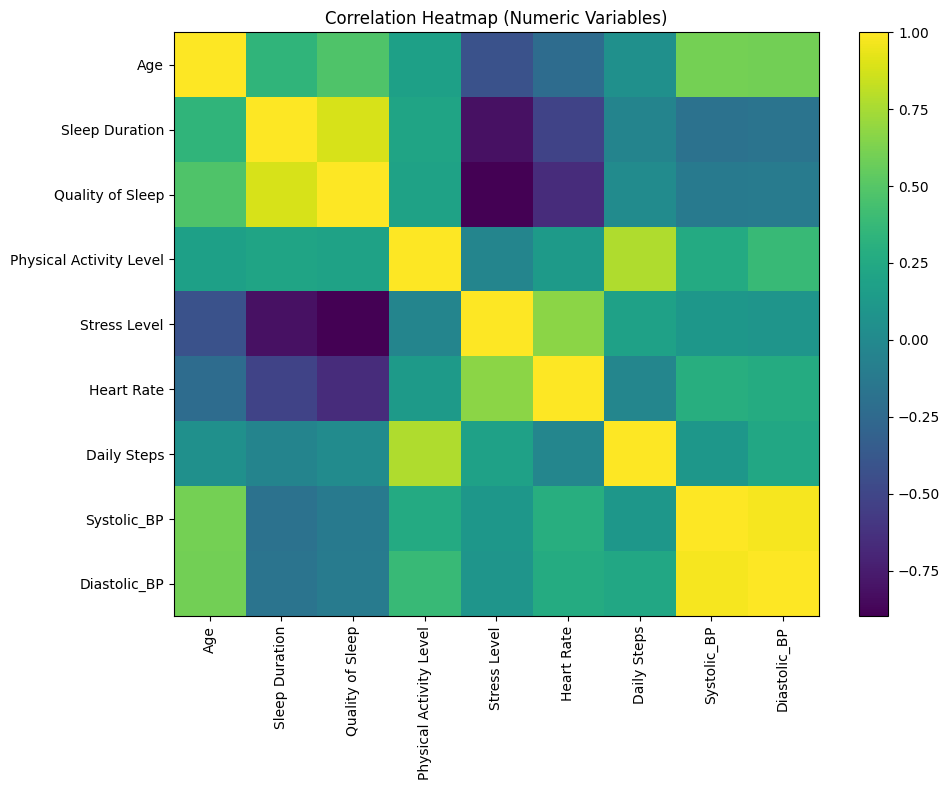

In [42]:
# Correlation heatmap (numeric variables)
corr_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()


## Conclusion & Real-World Application
Overall, physical activity and stress show meaningful relationships with sleep outcomes. Higher physical activity is associated with better sleep quality, while higher stress is linked to shorter sleep duration.

**Recommendations**
- Encourage regular physical activity and basic sleep hygiene routines.
- Promote stress-management strategies to support healthier sleep.

**Limitations**
- Observational dataset: correlation does not imply causation.
- Potential confounders may influence results (e.g., occupation, diet).
